# Selection of Relevant Track Infrastructure by Visual Inspection
Kooros Moabber Lule˚a University, Lule˚a, Sweden and Volvo Cars Corporation, Gothenburg, Sweden

## Introduction
Track infrastructure monitoring is critical for optimizing KPIs such as efficiency, cost, availability and safety. This monitoring is more crucial when the infrastructure is in a harsh environment and wore out due to age. Traditional maintenance is based on periodic inspections which is time consuming and costly and should be replaced with a predictive maintenance where an AI-driven approach for automated real time track monitoring is one of the best approaches. This monitoring can be done on all elements of infrastructure particularly turnouts, joins and bridges that are more vulnerable for any problem.

An approach for this monitoring is to measure the vibration detected caused by vehicle on track by accelerometer  in a specific infrastructure and combine this vibration data with GPS and expected/predefined infrastructure information to detect infrastructure elements (events) and compare their acceleration pattern with a normal pattern to detect any abnormally.

Qualified input data for any machine learning is a crucial. Unfortunately in the real world, input data either missing, corrupted, invalid or so much noisy and useless therefore selection of right methods to eliminate corrupted data and filter the data should be performed before data is used for any analysis specially for machine learning.

In this report, some track data are pre-processed and some suitable track information is selected for the AI-driven approach for automated real time track monitoring. 
 

## Method
The main method is reading the gathered data and performing visual inspect the data to recognize if the data fits to the pre-selected track. This data is going to be used later for elements (bridge, turn out and rail joint) detection. 

Some pre-processing like filtering out missing data, normalizing data and segmentation are done before any visual inspection. Besides, some visual features (like segment window and pre-selected track information) are added to visualize the data more effectively. 

Although some methods like checking the distance between Mora and Borlänge station is possible due to presence of speed and GPS data but after checking the data contents, they are not reliable and cannot cover all options therefore the visual inspection has been used to select the relevant data to specific track in this report. 

## Results and Analysis
For extracting data and analyzing them, first data files was read to extract map with all elements.

Let's start by importing the necessary packages (mostly from assignment 3):

In [1]:
import os
import pandas as pd
import numpy as np
import warnings
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import dash
from dash import dcc, html, Input, Output
import tkinter as tk
from tkinter import filedialog
from pathlib import Path
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

Before any action on files, the following powershell code is made a summary of whole 'Data2' folder report. This report is used to pre-filter all folders that 
- Don't have enough files (less than 6)
- Don't have enough data (size< 300KB)

Get-ChildItem -Directory | ForEach-Object {

    $files = Get-ChildItem $_.FullName -File -Recurse -ErrorAction SilentlyContinue

    [PSCustomObject]@{
    
        Folder     = $_.Name
        
        FileCount  = $files.Count

        TotalSizeMB = [math]::Round(($files | Measure-Object Length -Sum).Sum / 1MB, 2)
    }
} | Sort-Object Folder | Export-Csv "FolderReport.csv" -NoTypeInformation

In this step, by using Tkinter file dialog, the path of all five csv files (latitude, longitude, two vibration channels and speed) is asked. 

Besides, the data of these files are read and saved in a dataframe accumulator directory ('dataframes'). Besides, a synthetic 'timestamp' column by using the row index for future reference is added. Finally, marker file is read to add to the final figure and make readability and selection easier.

In [2]:
root = tk.Tk()
root.withdraw()  # Hide the root Tk window
root.wm_attributes('-topmost', True)   # forces dialog to appear on top

files = {}
dataframes = {}

# Define file keys and file name.
files_name = {
    "latitude":   "GPS.latitude.csv",
    "longitude":  "GPS.longitude.csv",
    "vibration1": "CH1_ACCEL1Z1.csv",
    "vibration2": "CH2_ACCEL1Z2.csv",
    "speed":      "GPS.speed.csv",
    "GPS_no":     "GPS.satellites.csv"
}

folder_path = filedialog.askdirectory(
    parent=root,
    title="Select Data Folder",
    initialdir=r"E:\Assignment4\Data2" 
)

if not folder_path:
    print("No folder selected!")

else:
    print(f"Folder selected: {folder_path}")
    for key, filename in files_name.items():
        file_path = os.path.join(folder_path, filename)
        if os.path.exists(file_path):
            files[key] = file_path
            df = pd.read_csv(file_path, header=None, names=[key])
            df['timestamp'] = df.index
            dataframes[key] = df
            p = Path(file_path)
            print(f"{key}: loaded from {filename} with {len(df)} rows")
        else:
            files[key] = None
            print(f"WARNING: {filename} not found in folder!")
    # Load marker data
    file_name_data="Data1/gps_marker_data.csv"
    data= pd.read_csv(file_name_data, encoding="utf-8")
    print(f"Marker data loaded")


Folder selected: E:/Assignment4/Data2/2024-12-10 10-00-00 (1)
latitude: loaded from GPS.latitude.csv with 36000 rows
longitude: loaded from GPS.longitude.csv with 36000 rows
vibration1: loaded from CH1_ACCEL1Z1.csv with 36000044 rows
vibration2: loaded from CH2_ACCEL1Z2.csv with 36000043 rows
speed: loaded from GPS.speed.csv with 36000 rows
GPS_no: loaded from GPS.satellites.csv with 36000 rows
Marker data loaded


In the next step, dataframes values are concatenated to a single dataframe. There are so many missing data in this concatenated dataframe due to different time sampling for vibration data (which is much more sampled) and GPS data.

In [3]:
'''combined = pd.concat(dataframes.values(), axis=1)
combined.info()
print(combined.head(7))
print("Missing values per column:\n", combined.isnull().sum())'''


'combined = pd.concat(dataframes.values(), axis=1)\ncombined.info()\nprint(combined.head(7))\nprint("Missing values per column:\n", combined.isnull().sum())'

First the GPS dataframe including latitude, longitude and its timestamp are saved in a single dataframe ('df_gps'). After making GPS dataframe, it is controlled for any invalid or missing data and the invalid data are removed. Dataframe is explored and partially monitored to briefly review the expected data. 

In [4]:
if "latitude" in dataframes and "longitude" in dataframes:
    df_gps = pd.merge(dataframes["latitude"], dataframes["longitude"], on="timestamp")
    # Rename columns for consistency
    df_gps = df_gps.rename(columns={"latitude": "Latitude", "longitude": "Longitude"})
    # Add an index column for use in the interactive plot
    df_gps["PointIndex"] = df_gps.index
    print("Missing values per column:\n", df_gps.isnull().sum())
    df_gps = df_gps.dropna()
    
    df_gps.info()
    print(df_gps[["Latitude", "Longitude", "PointIndex"]].head(3)) 

else:
    print("Latitude or Longitude data is missing.")
    df_gps = pd.DataFrame(columns=["Latitude", "Longitude", "PointIndex"])



Missing values per column:
 Latitude      0
timestamp     0
Longitude     0
PointIndex    0
dtype: int64
<class 'pandas.DataFrame'>
RangeIndex: 36000 entries, 0 to 35999
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Latitude    36000 non-null  float64
 1   timestamp   36000 non-null  int64  
 2   Longitude   36000 non-null  float64
 3   PointIndex  36000 non-null  int64  
dtypes: float64(2), int64(2)
memory usage: 1.1 MB
    Latitude  Longitude  PointIndex
0  60.904847  14.837729           0
1  60.904902  14.837636           1
2  60.904956  14.837545           2


As it can be recognized, there are limited number GPS data due to longer sampling time. 

Now the vibrations data from both channels (left and right) and virtual timestamp are merged and saved in a dataframe. Time stamp is added. This dataframe is also checked and invalid data are removed before any further analysis. Here also, d
ataframe is explored and partially monitored to briefly review the expected data.

In [5]:
if "vibration1" in dataframes and "vibration2" in dataframes:
    df_vibration_merged = pd.merge(dataframes["vibration1"],dataframes["vibration2"],on="timestamp")
    df_vibration_merged["timestamp"] = df_vibration_merged.index
    # Rename columns for consistency
    df_vibration_merged = df_vibration_merged.rename(columns={"vibration1": "Vibration1", "vibration2": "Vibration2"})
    print("Missing values per column:\n", df_vibration_merged.isnull().sum())
    df_vibration_merged = df_vibration_merged.dropna()
    df_vibration_merged.info()
    df_vibration_merged.head(5)
    df_vibration_merged.describe()
else:
    print("Vibration data files are missing.")
    df_vibration_merged = pd.DataFrame()




Missing values per column:
 Vibration1    0
timestamp     0
Vibration2    0
dtype: int64
<class 'pandas.DataFrame'>
RangeIndex: 36000043 entries, 0 to 36000042
Data columns (total 3 columns):
 #   Column      Dtype  
---  ------      -----  
 0   Vibration1  float64
 1   timestamp   int64  
 2   Vibration2  float64
dtypes: float64(2), int64(1)
memory usage: 824.0 MB


As it can be seen from the number of vibration data, vibration sensors have been sampled much faster (around 1000 time). Most probably it is related to hardware (HW) limitation or configured in the hardware (HW). This is very important to detect the right window and combine the data. It means each 1000 vibrations data should be dedicated to one GPS data.

Besides, descriptive statistical shows that vibration 2 signals has an offset of 2 (most probably due to HW setup), higher range and bigger standard deviations that presence less accurate data in channel 2.

Before any further manipulating vibration data, these vibrations data should be normalized since the vibration data has some offsets and they are in different range. Normalization has been done according to:
Normalize based on:
$$
x_{norm} = \frac{x - x_{mean}}{\sigma}
$$

In [6]:
# Vibration 1
vib1_min=df_vibration_merged["Vibration1"].min()
vib1_max=df_vibration_merged["Vibration1"].max()
vib1_mean=df_vibration_merged["Vibration1"].mean()
vib1_range=vib1_max-vib1_min
vib1_std=df_vibration_merged["Vibration1"].std()
print(f"Vibration 1: Min= {vib1_min}, Max= {vib1_max}, range= {vib1_range}, Std= {vib1_std} and mean== {vib1_mean}")

df_vibration_merged["Vibration1"]=(df_vibration_merged["Vibration1"]-vib1_mean)/(vib1_std)
vib1_min_n=df_vibration_merged["Vibration1"].min()
vib1_max_n=df_vibration_merged["Vibration1"].max()
vib1_mean_n=df_vibration_merged["Vibration1"].mean()
vib1_range_n=vib1_max_n-vib1_min_n
vib1_std_n=df_vibration_merged["Vibration1"].std()
print(f"Normalized Vibration 1: Min= {vib1_min_n}, Max= {vib1_max_n}, range= {vib1_range_n}, Std= {vib1_std_n} and mean== {vib1_mean_n}")

# Vibration 2
vib2_min=df_vibration_merged["Vibration2"].min()
vib2_max=df_vibration_merged["Vibration2"].max()
vib2_mean=df_vibration_merged["Vibration2"].mean()
vib2_range=vib2_max-vib2_min
vib2_std=df_vibration_merged["Vibration2"].std()
print(f"Vibration 2: Min= {vib2_min}, Max= {vib2_max}, range= {vib2_range}, Std= {vib2_std} and mean== {vib2_mean}")

df_vibration_merged["Vibration2"]=(df_vibration_merged["Vibration2"]-vib2_mean)/(vib2_std)
vib2_min_n=df_vibration_merged["Vibration2"].min()
vib2_max_n=df_vibration_merged["Vibration2"].max()
vib2_range_n=vib2_max_n-vib2_min_n
df_vibration_merged["Vibration2"]=df_vibration_merged["Vibration2"]*(vib1_range_n/vib2_range_n)
vib2_min_n=df_vibration_merged["Vibration2"].min()
vib2_max_n=df_vibration_merged["Vibration2"].max()
vib2_mean_n=df_vibration_merged["Vibration2"].mean()
vib2_range_n=vib2_max_n-vib2_min_n
vib2_std_n=df_vibration_merged["Vibration2"].std()
print(f"Normalized Vibration 2: Min= {vib2_min_n}, Max= {vib2_max_n}, range= {vib2_range_n}, Std= {vib2_std_n} and mean== {vib2_mean_n}")


Vibration 1: Min= -42.3571690166636, Max= 36.1312030763596, range= 78.4883720930232, Std= 1.1610208262284418 and mean== 0.123281268484893
Normalized Vibration 1: Min= -36.58887879138704, Max= 31.014018865489156, range= 67.6028976568762, Std= 0.9999999999999999 and mean== 1.5461391462366645e-17
Vibration 2: Min= -113.021119453092, Max= 114.99725325032, range= 228.018372703412, Std= 1.48590285660009 and mean== 2.0942076127492553
Normalized Vibration 2: Min= -34.129397478387695, Max= 33.47350017848849, range= 67.6028976568762, Std= 0.4405405474648085 and mean== -2.056466119340923e-17


The results show the normalized vibration data without any offset.

The speed data has been read to shown later. it can be helpful to filter out unnecessary data.

finally, let's visualize these data before any manipulation. 

<class 'pandas.DataFrame'>
RangeIndex: 36000 entries, 0 to 35999
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   speed      36000 non-null  float32
 1   timestamp  36000 non-null  int64  
 2   speed_mps  36000 non-null  float32
 3   distance   36000 non-null  float32
dtypes: float32(3), int64(1)
memory usage: 703.3 KB
        speed  timestamp  speed_mps  distance
0  142.468506          0  39.574585  1.978729
1  142.283508          1  39.523197  3.954889
2  142.357498          2  39.543751  5.932077
3  142.449997          3  39.569443  7.910549
4  142.524002          4  39.590000  9.890049
<class 'pandas.DataFrame'>
RangeIndex: 36000 entries, 0 to 35999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   GPS_no     36000 non-null  int64
 1   timestamp  36000 non-null  int64
dtypes: int64(2)
memory usage: 562.6 KB
   GPS_no  timestamp
0       4          0
1   

Text(0.5, 0, 'Time')

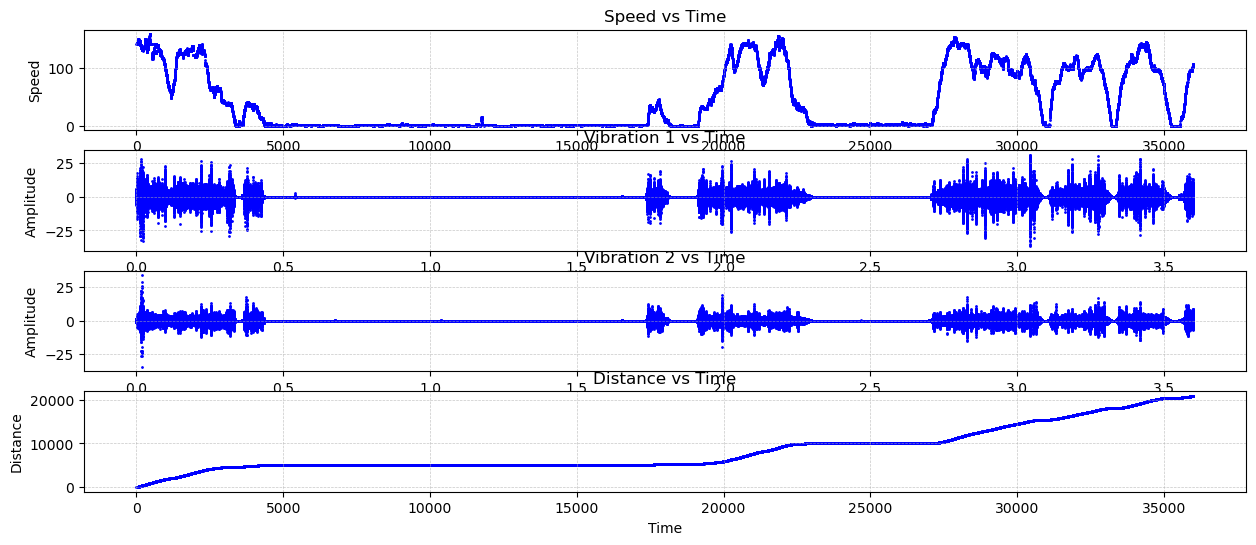

In [13]:
gps_delta_t = 0.05  # 20 Hz

if "speed" in dataframes:
    df_speed = dataframes["speed"].copy()

    df_speed["speed"] = df_speed["speed"].astype("float32")
    df_speed["speed_mps"] = df_speed["speed"] / 3.6
    df_speed["distance"] = (df_speed["speed_mps"] * gps_delta_t).cumsum()

    # only if timestamp exists
    if "timestamp" in df_speed:
        df_speed["timestamp"] = df_speed["timestamp"]
    else:
        df_speed["timestamp"] = df_speed.index * gps_delta_t

    df_speed.info()
    print(df_speed.head(5))
else:
    df_speed = pd.DataFrame()

if "GPS_no" in dataframes:
    df_gps_no=dataframes["GPS_no"]
    df_gps_no.info()
    print(df_gps_no.head(5))
else:
    df_gps_no = pd.DataFrame()

plt.figure(figsize=(15, 6)) # wider figures holder

plt.subplot(4, 1, 1)
plt.scatter(df_speed['timestamp'],df_speed['speed'], c='blue', s=1)
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
plt.title("Speed vs Time")
plt.ylabel("Speed")
plt.xlabel("Time")

plt.subplot(4, 1, 2)
plt.scatter(df_vibration_merged['timestamp'],df_vibration_merged['Vibration1'], c='blue', s=1)
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
plt.title("Vibration 1 vs Time")
plt.ylabel("Amplitude")
plt.xlabel("Time")

plt.subplot(4, 1, 3)
plt.scatter(df_vibration_merged['timestamp'],df_vibration_merged['Vibration2'], c='blue', s=1)
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
plt.title("Vibration 2 vs Time")
plt.ylabel("Amplitude")
plt.xlabel("Time")

plt.subplot(4, 1, 4)
plt.scatter(df_speed['timestamp'],df_speed["distance"], c='blue', s=1)
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
plt.title("Distance vs Time")
plt.ylabel("Distance")
plt.xlabel("Time")

The speed data shows the train is not always running and there many stops in the middle of the way. these GPS data and dedicated vibration data can be eliminated to reduce the file size.

In this stage, the vibration signal into X second windows with a 500 Hz (1/0.002) sampling rate is sliced. The vibration data is saved in a 3D numeric matrix where the rows show the vibration data for all 10 second slices, columns show the vibrations data of each slide (10 second) and the third dimension shows the two channel vibrations data.

In [14]:
# ====================
# Data Preprocessing and Segmentation for Vibration Data
# ====================
dt_vibration = 0.002  # seconds per sample (e.g. 500 Hz sampling rate)
segment_duration_seconds = 5000
vib_segment_length = int(segment_duration_seconds / dt_vibration)
print(f"Vibration segment length: {vib_segment_length}")
if not df_vibration_merged.empty:
    vib_num_segments = len(df_vibration_merged) // vib_segment_length
    print(f"Vibration number of segments: {vib_num_segments}")
    vib_segments = []
    for i in range(vib_num_segments):
        vib_seg = df_vibration_merged.iloc[i * vib_segment_length: (i + 1) * vib_segment_length][["Vibration1", "Vibration2"]].values
        vib_segments.append(vib_seg)
    vib_segments = np.array(vib_segments)
    print("Segmented vibration data shape:", vib_segments.shape)
else:
    vib_segments = np.array([])
    print("No vibration data available for segmentation.")



Vibration segment length: 2500000
Vibration number of segments: 14
Segmented vibration data shape: (14, 2500000, 2)


The same data processing has been done for GPS data to have the same number of rows where each row of GPS data is relevant to the same row of the vibration data. This is necessary to show right vibration data for each GPS point.

In [15]:
# ====================
# Data Preprocessing and Segmentation for GPS Data
# ====================
if not df_gps.empty:
    gps_num_segments=vib_num_segments
    gps_segment_length = len(df_gps) // gps_num_segments
    gps_segments = []
    for i in range(gps_num_segments):
        gps_seg = df_gps.iloc[i * gps_segment_length: (i + 1) * gps_segment_length]
        gps_segments.append(gps_seg)
    print(f"GPS segment length: {gps_segment_length}")
    print(f"GPS number of segments: {len(gps_segments)}")
    print(gps_segments[2].head(5))
else:
    gps_segments = []
    print("No GPS data available for segmentation.")

GPS segment length: 2571
GPS number of segments: 14
       Latitude  timestamp  Longitude  PointIndex
5142  61.004463       5142  14.542235        5142
5143  61.004463       5143  14.542235        5143
5144  61.004464       5144  14.542235        5144
5145  61.004464       5145  14.542236        5145
5146  61.004464       5146  14.542235        5146


In this part an interactive web dashboard is configured where it contains 2 panels (graphs) where the left panel shows every read GPS point from GPS dataframe on an OpenStreetMap base map and the right panel shows one period of the vibration data (10s) on the vibration plots when a point on a map is selected. Base map figure with GPS data and an empty vibration panel are illustrated with all added cosmetics data like titles and axes labels. 

In [16]:
# ====================
# Build the Interactive Dash App
# ====================

# Create the interactive GPS map using Plotly Express.
warnings.filterwarnings("ignore") # to remove warning for the old scatter_mapbox command

# Marker data
marker_styles = {
    "Bridge": {"color": "red", "size": 5},
    "RailJoint": {"color": "blue", "size": 4},
    "Turnout": {"color": "green", "size": 6}
}
if not df_gps.empty:
    # Use custom_data to store the point index so that it will be available in callbacks.
    map_fig = px.scatter_mapbox(
        df_gps,
        lat="Latitude",
        lon="Longitude",
        custom_data=["PointIndex"],
        zoom=8.5,
        center=dict(lat=df_gps["Latitude"].mean(), lon=df_gps["Longitude"].mean()),
        hover_data=[df_gps["timestamp"],df_gps_no["GPS_no"]],
        size_max=20,
        title="GPS Points with Vibration Data"
    )
    map_fig.update_layout(mapbox_style="open-street-map", width=1200, height=800)
    for category, style in marker_styles.items():
        category_data = data[data["Category"] == category]
        
        if len(category_data) > 0:
            map_fig.add_trace(go.Scattermapbox(
                lat=category_data["Latitude"],
                lon=category_data["Longitude"],
                mode="markers",
                marker=dict(
                    color=style["color"],
                    size=style["size"]
                ),
                name=category
            ))
        else:
            print(f"Skipping {category} - no data available")
else:
    map_fig = go.Figure()
    map_fig.update_layout(title="No GPS Data Available", width=1200, height=800)

# Create an initial empty vibration plot figure.
vib_empty_fig = go.Figure()
vib_empty_fig.update_layout(
    title="Vibration Signal",
    xaxis_title="Time (s)",
    yaxis_title="Acceleration"
)

# Initialize Dash app.
app = dash.Dash(__name__)

app.layout = html.Div([
    html.Div([
        dcc.Graph(id="gps-map", figure=map_fig)
    ], style={'width': '100%', 'height': '100vh', 'display': 'block'}),
    html.Div([
        dcc.Graph(id="vibration-plot", figure=vib_empty_fig)
    ], style={'width': '100%',  'height': '100vh', 'display': 'block'})
    #,
     #html.Div([
      #  dcc.Graph(id="vibration-plot", figure=vib_empty_fig)
    #], style={'width': '100%',  'height': '33vh', 'display': 'block'})
], style={
    'width': '1200px',       # match panel width
    'height': '200vh',      # 800 + 800 for both panels
    'margin': '0 auto',      # center in browser
    'overflow-y': 'scroll'   # scroll if screen is smaller
})


Although dashboard was configured to show base map and GPS data, vibrations data is shown based on an interaction interface with user. As soon as a user select a GPS point, the relevant segment of this GPS data is found and the same data frame segment of vibration is presented.

In [17]:
# --------------------
# Callback to Update the Vibration Plot Based on Clicked GPS Point
# --------------------
vib_fig = None

@app.callback(
    Output('vibration-plot', 'figure'),
    Output('gps-map', 'figure'),
    [Input('gps-map', 'clickData')]
)
def update_vibration_plot(clickData):
    # If no point is selected, return the empty vibration figure.
    if clickData is None:
        return vib_empty_fig, map_fig 
    
    # Debug: print what clickData actually contains
    point = clickData['points'][0]
    # print("clickData received:", point.keys())
    # customdata = clickData['customdata'][0]
    # print("Full cutom data data:", customdata)

    # Safe extraction
    if 'customdata' in point:
        point_index = int(point['customdata'][0])
    elif 'pointIndex' in point:
        point_index = int(point['pointIndex'])
    else:
        point_index = 0
        

    # Retrieve the selected GPS point index from custom_data.
    # point_index = clickData['points'][0]['customdata'][0]

    if vib_segments.size == 0:
        empty_fig = go.Figure()
        empty_fig.update_layout(
            title="No Vibration Data Available",
            xaxis_title="Time (s)",
            yaxis_title="Acceleration"
        )
        #return empty_fig
        return empty_fig, map_fig

    # Map the GPS point to a vibration segment. If the selected index exceeds
    # the available number of segments, use the last segment as fallback.
    # print(f"Point Index: {point_index}, Latitude: {point['lat']}, Longitude: {point['lon']}")
    gps_selected_segment=point_index//gps_segment_length
    # print(f"GPS Selected segment: {gps_selected_segment}")
    if gps_selected_segment < vib_segments.shape[0]:
         vib_selected_segment = vib_segments[gps_selected_segment]
    else:
        vib_selected_segment = vib_segments[-1]
    # print(selected_segment.shape)

    # if segment_index < segments.shape[0]:
    #    selected_segment = segments[segment_index]
    #else:
    #    selected_segment = segments[-1]
    #print(f": point_index: {point_index} @ time: {gps_time},Segments dimension: {segments.shape[0]}, Selected segments: {selected_segment}")

        updated_map = go.Figure(map_fig)   # copy original map

    # Get the GPS points for selected segment
    seg_start = gps_selected_segment * gps_segment_length
    seg_end   = seg_start + gps_segment_length
    selected_gps = df_gps.iloc[seg_start:seg_end]

    # Add highlighted segment as a new trace

    # ====================
    # Build updated map with highlighted segment
    # ====================
    updated_map = go.Figure(map_fig)   # copy original map

    # Get the GPS points for selected segment
    seg_start = gps_selected_segment * gps_segment_length
    seg_end   = seg_start + gps_segment_length
    selected_gps = df_gps.iloc[seg_start:seg_end]

    # ====================
    # Draw bounding box around selected segment
    # ====================
    updated_map = go.Figure(map_fig)

    # Get lat/lon bounds of selected segment
    selected_gps = df_gps.iloc[seg_start:seg_end]
    lat_min = selected_gps["Latitude"].min()
    lat_max = selected_gps["Latitude"].max()
    lon_min = selected_gps["Longitude"].min()
    lon_max = selected_gps["Longitude"].max()

    # Draw rectangle as a closed line trace
    updated_map.add_trace(go.Scattermapbox(
        lat=[lat_min, lat_max, lat_max, lat_min, lat_min],  # close the box
        lon=[lon_min, lon_min, lon_max, lon_max, lon_min],  # close the box
        mode="lines",
        line=dict(color="yellow", width=3),
        name=f"Segment {gps_selected_segment}",
        showlegend=False
    ))

   
    # Create a time axis for the selected segment.
    time_axis = np.arange(vib_segment_length) * dt_vibration

    vib_fig = go.Figure()
    vib_fig.add_trace(go.Scatter(
        x=time_axis,
        y=vib_selected_segment[:, 0],
        mode='lines',
        name='Vibration Channel 1'
    ))
    vib_fig.add_trace(go.Scatter(
        x=time_axis,
        y=vib_selected_segment[:, 1],
        mode='lines',
        name='Vibration Channel 2'
    ))
    vib_fig.update_layout(
        title=f"Vibration Signal for GPS Point {point_index},GPS Selected segment: {gps_selected_segment}, Latitude: {point['lat']}, Longitude: {point['lon']}",
        xaxis_title="Time (s)",
        yaxis_title="Acceleration"
    )

    """file_name_vib=f"{p.parent}/vib_data.png"
    vib_fig.write_image(
    file_name_vib ,
    width=1200,       # pixels
    height=800,       # pixels
    scale=2           # scale=2 doubles resolution (good for reports)
    )"""
    #return vib_fig
    return vib_fig, updated_map



In this part, the app is run to show the interactive environment for user to see GPS point and dedicated vibration data in the pre-selected period of time. To make it easier, a yellow box shows the duration of this pre-selected period of time. In addition, the elements have been added to graph.

In [18]:
# ====================
# Run the Dash App
# ====================
if __name__ == "__main__":
    app.run(debug=False, port=8060)

These graphs visualize that GPS data and dedicated vibrations are relevant to the elements.

In [19]:
flag=input("Save data (Y/N)?")
if flag.upper()=="Y":
    p = Path(file_path)
    file_name_map=f"{p.parent}/map_data.png"
    map_fig.write_image(
        file_name_map ,
        width=1200,       # pixels
        height=800,       # pixels
        scale=2           # scale=2 doubles resolution (good for reports)
    )
    
    #file_name_df_combined=f"{p.parent}/combined_data.csv"
    #combined.to_csv(file_name_df_combined, index=False)
    file_name_df_gps_no=f"{p.parent}/gps_no_data.csv"
    df_gps_no.to_csv(file_name_df_gps_no, index=False)
    file_name_df_gps=f"{p.parent}/gps_data.csv"
    df_gps.to_csv(file_name_df_gps, index=False)
    file_name_speed=f"{p.parent}/Speed_data.csv"
    df_speed.to_csv(file_name_speed, index=False)
    file_name_df_vibration_merged=f"{p.parent}/vibration_data.csv"
    df_vibration_merged.to_csv(file_name_df_vibration_merged, index=False)
    print(f"{p.parent}: Map, GPS and Vibration profiles are saved!")
else:
    print("Thanks")
    file_name_empty=f"{p.parent}/useless.txt"
    open(file_name_empty, "w").close()
    print(f"{p.parent} hasn't been saved")
    


Save data (Y/N)? y


E:\Assignment4\Data2\2024-12-10 10-00-00 (1): Map, GPS and Vibration profiles are saved!


## Discussion and Summary
Pre-Analysis of files has illustrated that there are many folders of data that can be filter out without running this code due to:
- lack of necessary files 
- files with zero size 
- Small files

They have been categorized and saved in useless folder (30 files).

For remaining folders above code has been modified to be user friendly. There are many modifications in code for better visualization and readability and inspection for example in the interaction map, marker point, vibration data, GPS satellite number and yellow box to show the selected segment have been added. 

They results have been categorized as:
- Bad data: when the GPS data is irrelevant to the pre-selected path (min and max of altitude and longitude of GPS data of marker file and 'Data2' folders contents GPS data) or train stops in station (by checking speed file) that are saved in separately in 'bad' folder (92 files).
- Maybe data: when they have a small piece of data but they can still be used if there is lack of data. The map, vibration profile for specific segment and data frames are saved in a separate csv files in the same folder of data and the final folder is saved in 'maybe' (5 files).
- Good data: when they have enough knowledge or with small modifications, they can be used for our main coding. The map, vibration profile for specific segment and data frames are saved in a separate csv files in the same folder of data (9 files).

In summary, the final 9 selected files are selected but none of them is completely ready for analysis due to lack of whole data, extra GPS, bad vibration data and so on that pushes further filtering and data combination. 


## Future Work
This step is really time consuming and difficult to make it fully automatic although some efforts have been done here and there are some specific methods but it needs more time that due to limited deadline, I will perform it after delivery. All good data are going to be used in the next step of coding.